# Problem 3: Credit Card Transaction Fraud Detection with Google TabFM

## Problem
Millions of credit card transactions occur daily. Only a tiny fraction are fraudulent, but losses are large.

## What we do
Build a fraud classifier that predicts whether a transaction is fraudulent *before approval*.

## Business goals
- Block fraudulent transactions
- Reduce financial losses
- Minimize false positives to avoid customer friction

This notebook is production-oriented: reproducible setup, web download, leakage-safe splits, imbalance-aware evaluation, threshold policy optimization, and deployable artifacts.

## 0) Why this design

### Dataset choice
We use the widely adopted **Credit Card Fraud Detection** dataset (European card transactions) served directly from the web URL hosted by TensorFlow:
`https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv`

Why this dataset:
- Realistic extreme class imbalance
- Sufficient scale for operational fraud modeling
- Stable schema for end-to-end demonstrations in constrained compute

### Modeling strategy
- Baseline: XGBoost (strong tabular baseline)
- Foundation model: **Google TabFM** (3 variants)
- Metric priority: PR-AUC, recall on fraud class, and cost-sensitive thresholding

### Caveat
The dataset is anonymized PCA-like features (`V1..V28`) and lacks raw fields like merchant category/device ID/location. We still implement production-grade workflow and action policy with available columns.

## 1) Reproducible setup

Optional environment variables:

- `TABFM_DEVICE=auto|cpu|cuda`
- `FRAUD_DATA_URL=https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv`
- `FRAUD_SAMPLE_TRAIN_ROWS=100000` (0 means full split)
- `FRAUD_SAMPLE_EVAL_ROWS=60000` (0 means full split)
- `FRAUD_MIN_SAMPLE_ROWS=2000`
- `TABFM_CONTEXT_MAX_ROWS=2500`
- `TABFM_EVAL_MAX_ROWS=3000` (0 means full val/test for model comparison)
- `TABFM_FAST_MODE=0|1` (1 = constrained smoke execution)
- `TABFM_CHECKPOINT_PATH=/abs/path/to/pytorch_model.bin` (optional)

License note:
- TabFM code is Apache-2.0.
- Released TabFM weights from Google are non-commercial; review terms before commercial deployment.

In [1]:
from __future__ import annotations

import json
import os
import random
import shutil
import subprocess
import time
import urllib.request
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns
import torch
from loguru import logger
from sklearn.calibration import calibration_curve
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    brier_score_loss,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from xgboost import XGBClassifier

from tabfm import TabFMClassifier
from tabfm import tabfm_v1_0_0_pytorch as tabfm_v1_0_0

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

TABFM_DEVICE_PREF = os.getenv('TABFM_DEVICE', 'auto').lower().strip()
if TABFM_DEVICE_PREF not in {'auto', 'cpu', 'cuda'}:
    raise ValueError(f'Unsupported TABFM_DEVICE={TABFM_DEVICE_PREF}')

DATA_URL = os.getenv('FRAUD_DATA_URL', 'https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv').strip()
SAMPLE_TRAIN_ROWS = int(os.getenv('FRAUD_SAMPLE_TRAIN_ROWS', '100000'))
SAMPLE_EVAL_ROWS = int(os.getenv('FRAUD_SAMPLE_EVAL_ROWS', '60000'))
MIN_SAMPLE_ROWS = int(os.getenv('FRAUD_MIN_SAMPLE_ROWS', '2000'))
TABFM_CONTEXT_MAX_ROWS = int(os.getenv('TABFM_CONTEXT_MAX_ROWS', '2500'))
TABFM_EVAL_MAX_ROWS = int(os.getenv('TABFM_EVAL_MAX_ROWS', '3000'))
TABFM_FAST_MODE = os.getenv('TABFM_FAST_MODE', '0').strip() == '1'

if SAMPLE_TRAIN_ROWS != 0 and SAMPLE_TRAIN_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'FRAUD_SAMPLE_TRAIN_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if SAMPLE_EVAL_ROWS != 0 and SAMPLE_EVAL_ROWS <= MIN_SAMPLE_ROWS:
    raise ValueError(f'FRAUD_SAMPLE_EVAL_ROWS must be 0 or > {MIN_SAMPLE_ROWS}')
if TABFM_CONTEXT_MAX_ROWS <= 500:
    raise ValueError('TABFM_CONTEXT_MAX_ROWS must be > 500 for stable TabFM context fitting.')
if TABFM_EVAL_MAX_ROWS != 0 and TABFM_EVAL_MAX_ROWS <= 500:
    raise ValueError('TABFM_EVAL_MAX_ROWS must be 0 or > 500.')


def resolve_tabfm_device(preference: str) -> str:
    if preference == 'auto':
        return 'cuda' if torch.cuda.is_available() else 'cpu'
    if preference == 'cuda' and not torch.cuda.is_available():
        logger.warning('TABFM_DEVICE=cuda requested but CUDA unavailable; falling back to cpu')
        return 'cpu'
    return preference


def find_project_root(start: Path) -> Path:
    for cand in [start, *start.parents]:
        if (cand / 'pyproject.toml').exists():
            return cand
    raise RuntimeError('Could not find project root (pyproject.toml not found).')


PROJECT_ROOT = find_project_root(Path.cwd())
PROBLEM_ROOT = PROJECT_ROOT / 'problems' / 'problem3_credit_card_transaction_fraud'
DATA_DIR = PROBLEM_ROOT / 'data' / 'raw'
ARTIFACT_DIR = PROBLEM_ROOT / 'artifacts'
MODEL_CACHE_DIR = PROBLEM_ROOT / 'data' / 'models' / 'google-tabfm-1.0.0-pytorch'

DATA_DIR.mkdir(parents=True, exist_ok=True)
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_CACHE_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = resolve_tabfm_device(TABFM_DEVICE_PREF)

logger.info('Project root: {}', PROJECT_ROOT)
logger.info('Problem root: {}', PROBLEM_ROOT)
logger.info('Raw data dir: {}', DATA_DIR)
logger.info('Artifacts dir: {}', ARTIFACT_DIR)
logger.info('TabFM device preference={} effective={}', TABFM_DEVICE_PREF, DEVICE)
logger.info('Sample train/eval rows: {}/{} (0 means full)', SAMPLE_TRAIN_ROWS, SAMPLE_EVAL_ROWS)
logger.info('TabFM context max rows: {}', TABFM_CONTEXT_MAX_ROWS)
logger.info('TabFM eval max rows: {} (0 means full)', TABFM_EVAL_MAX_ROWS)
logger.info('TabFM fast mode: {}', TABFM_FAST_MODE)

sns.set_theme(style='whitegrid')

2026-07-03 03:32:28.122 | INFO     | __main__:<module>:97 - Project root: /home/ahmad/AI/Github/google-tabFM-implementation


2026-07-03 03:32:28.123 | INFO     | __main__:<module>:98 - Problem root: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud


2026-07-03 03:32:28.123 | INFO     | __main__:<module>:99 - Raw data dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/data/raw


2026-07-03 03:32:28.123 | INFO     | __main__:<module>:100 - Artifacts dir: /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts


2026-07-03 03:32:28.124 | INFO     | __main__:<module>:101 - TabFM device preference=auto effective=cuda


2026-07-03 03:32:28.124 | INFO     | __main__:<module>:102 - Sample train/eval rows: 15000/8000 (0 means full)


2026-07-03 03:32:28.124 | INFO     | __main__:<module>:103 - TabFM context max rows: 1200


2026-07-03 03:32:28.125 | INFO     | __main__:<module>:104 - TabFM eval max rows: 1000 (0 means full)


2026-07-03 03:32:28.125 | INFO     | __main__:<module>:105 - TabFM fast mode: True


## 2) Download dataset directly from web (idempotent)

This cell downloads the CSV only if it is missing locally.

In [2]:
DATA_CSV = DATA_DIR / 'creditcard.csv'

if DATA_CSV.exists() and DATA_CSV.stat().st_size > 0:
    logger.info('Using existing dataset at {} ({:.1f} MB)', DATA_CSV, DATA_CSV.stat().st_size / (1024**2))
else:
    logger.info('Downloading dataset from {} ...', DATA_URL)
    urllib.request.urlretrieve(DATA_URL, DATA_CSV)
    logger.info('Downloaded dataset to {} ({:.1f} MB)', DATA_CSV, DATA_CSV.stat().st_size / (1024**2))

DATA_CSV

2026-07-03 03:32:28.129 | INFO     | __main__:<module>:4 - Using existing dataset at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/data/raw/creditcard.csv (143.8 MB)


PosixPath('/home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/data/raw/creditcard.csv')

## 3) Load and audit data

In [3]:
df = pd.read_csv(DATA_CSV)

if 'Class' not in df.columns:
    raise ValueError('Dataset missing target column: Class')

# Add stable transaction id for downstream traceability.
df.insert(0, 'transaction_id', np.arange(len(df), dtype=np.int64))

logger.info('Loaded shape: {}', df.shape)
logger.info('Columns: {}', df.columns.tolist())

class_counts = df['Class'].value_counts(dropna=False).sort_index()
fraud_rate = float(df['Class'].mean())
logger.info('Class distribution: {}', class_counts.to_dict())
logger.info('Fraud rate: {:.4%}', fraud_rate)

summary_df = pd.DataFrame({
    'metric': ['rows', 'columns', 'fraud_rate', 'fraud_count', 'nonfraud_count', 'amount_mean', 'amount_p99'],
    'value': [
        len(df),
        df.shape[1],
        fraud_rate,
        int(class_counts.get(1, 0)),
        int(class_counts.get(0, 0)),
        float(df['Amount'].mean()),
        float(df['Amount'].quantile(0.99)),
    ],
})
summary_df

2026-07-03 03:32:29.171 | INFO     | __main__:<module>:9 - Loaded shape: (284807, 32)


2026-07-03 03:32:29.172 | INFO     | __main__:<module>:10 - Columns: ['transaction_id', 'Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class']


2026-07-03 03:32:29.174 | INFO     | __main__:<module>:14 - Class distribution: {0: 284315, 1: 492}


2026-07-03 03:32:29.175 | INFO     | __main__:<module>:15 - Fraud rate: 0.1727%


,metric,value
0,rows,284807.000000
1,columns,32.000000
2,fraud_rate,0.001727
3,fraud_count,492.000000
4,nonfraud_count,284315.000000
5,amount_mean,88.349619
6,amount_p99,1017.970000


/tmp/ipykernel_320875/665241312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='deep')


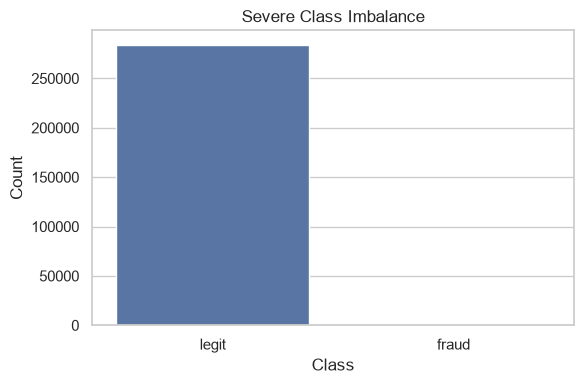

In [4]:
plt.figure(figsize=(6, 4))
plot_counts = df['Class'].value_counts().rename(index={0: 'legit', 1: 'fraud'})
sns.barplot(x=plot_counts.index, y=plot_counts.values, palette='deep')
plt.title('Severe Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## 4) Leakage-safe feature engineering

Features engineered from current transaction fields only.

- Numeric transforms: `amount_log1p`
- Time decomposition: hour/day/weekend indicators from `Time`
- Categorical bins: `amount_bucket`, `hour_bucket`

Target column is `Class` (1 = fraud).

In [5]:
def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()

    out['amount_log1p'] = np.log1p(out['Amount'].clip(lower=0.0))
    out['hour_of_day'] = ((out['Time'] // 3600) % 24).astype(int)
    out['day_index'] = (out['Time'] // 86400).astype(int)
    out['is_weekend'] = ((out['day_index'] % 7).isin([5, 6])).astype(int)

    # Discretized buckets for mixed-type modeling.
    out['amount_bucket'] = pd.qcut(
        out['Amount'].rank(method='first'),
        q=10,
        labels=[f'a{i}' for i in range(10)],
    ).astype(str)

    out['hour_bucket'] = pd.cut(
        out['hour_of_day'],
        bins=[-1, 5, 11, 17, 23],
        labels=['night', 'morning', 'afternoon', 'evening'],
    ).astype(str)

    return out


feature_df = engineer_features(df)
feature_df[['transaction_id', 'Time', 'Amount', 'amount_log1p', 'hour_of_day', 'hour_bucket', 'amount_bucket', 'Class']].head()

,transaction_id,Time,Amount,amount_log1p,hour_of_day,hour_bucket,amount_bucket,Class
0,0,0.0,149.62,5.014760,0,night,a8,0
1,1,0.0,2.69,1.305626,0,night,a1,0
2,2,1.0,378.66,5.939276,0,night,a9,0
3,3,1.0,123.50,4.824306,0,night,a8,0
4,4,2.0,69.99,4.262539,0,night,a7,0


## 5) Train/validation/test split with class-aware row caps

We split first (stratified) and then optionally cap rows per split to control runtime while preserving fraud cases.

In [6]:
TARGET_COL = 'Class'
META_COLS = ['transaction_id', 'Amount', 'Time']


def cap_split_rows(df_split: pd.DataFrame, max_rows: int, seed: int, target_col: str, min_pos: int = 40) -> pd.DataFrame:
    if max_rows == 0 or len(df_split) <= max_rows:
        return df_split.sample(frac=1.0, random_state=seed).reset_index(drop=True)

    pos = df_split[df_split[target_col] == 1]
    neg = df_split[df_split[target_col] == 0]

    if len(pos) == 0:
        return df_split.sample(n=max_rows, random_state=seed).reset_index(drop=True)

    # Keep enough positives for stable PR-AUC/recall comparisons in capped runs.
    desired_pos = min(len(pos), max(min_pos, int(round(max_rows * len(pos) / len(df_split)))))
    desired_pos = min(desired_pos, max_rows - 1)
    desired_neg = max_rows - desired_pos

    pos_sample = pos.sample(n=desired_pos, random_state=seed)
    neg_sample = neg.sample(n=desired_neg, random_state=seed)
    capped = pd.concat([pos_sample, neg_sample], axis=0).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return capped


train_full, holdout = train_test_split(
    feature_df,
    test_size=0.30,
    random_state=SEED,
    stratify=feature_df[TARGET_COL],
)
val_full, test_full = train_test_split(
    holdout,
    test_size=0.50,
    random_state=SEED,
    stratify=holdout[TARGET_COL],
)

train_df = cap_split_rows(train_full, SAMPLE_TRAIN_ROWS, seed=SEED + 1, target_col=TARGET_COL)
val_df = cap_split_rows(val_full, SAMPLE_EVAL_ROWS, seed=SEED + 2, target_col=TARGET_COL)
test_df = cap_split_rows(test_full, SAMPLE_EVAL_ROWS, seed=SEED + 3, target_col=TARGET_COL)

for name, frame in [('train', train_df), ('val', val_df), ('test', test_df)]:
    fraud_n = int(frame[TARGET_COL].sum())
    logger.info('{} split -> rows={} fraud={} fraud_rate={:.4%}', name, len(frame), fraud_n, frame[TARGET_COL].mean())

pd.DataFrame([
    {'split': 'train', 'rows': len(train_df), 'fraud_rows': int(train_df[TARGET_COL].sum()), 'fraud_rate': float(train_df[TARGET_COL].mean())},
    {'split': 'val', 'rows': len(val_df), 'fraud_rows': int(val_df[TARGET_COL].sum()), 'fraud_rate': float(val_df[TARGET_COL].mean())},
    {'split': 'test', 'rows': len(test_df), 'fraud_rows': int(test_df[TARGET_COL].sum()), 'fraud_rate': float(test_df[TARGET_COL].mean())},
])

2026-07-03 03:32:29.658 | INFO     | __main__:<module>:45 - train split -> rows=15000 fraud=40 fraud_rate=0.2667%


2026-07-03 03:32:29.659 | INFO     | __main__:<module>:45 - val split -> rows=8000 fraud=40 fraud_rate=0.5000%


2026-07-03 03:32:29.660 | INFO     | __main__:<module>:45 - test split -> rows=8000 fraud=40 fraud_rate=0.5000%


,split,rows,fraud_rows,fraud_rate
0,train,15000,40,0.002667
1,val,8000,40,0.005000
2,test,8000,40,0.005000


## 6) Modeling helpers and XGBoost baseline

In [7]:
def evaluate_classifier(y_true: np.ndarray, y_score: np.ndarray, threshold: float = 0.5) -> dict[str, float]:
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    y_pred = (y_score >= threshold).astype(int)

    return {
        'roc_auc': float(roc_auc_score(y_true, y_score)),
        'pr_auc': float(average_precision_score(y_true, y_score)),
        'brier': float(brier_score_loss(y_true, y_score)),
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(y_true, y_pred, zero_division=0)),
        'recall': float(recall_score(y_true, y_pred, zero_division=0)),
        'f1': float(f1_score(y_true, y_pred, zero_division=0)),
    }


def make_model_xy(frame: pd.DataFrame) -> tuple[pd.DataFrame, np.ndarray, pd.DataFrame]:
    y = frame[TARGET_COL].to_numpy(dtype=np.int32)
    meta = frame[META_COLS].reset_index(drop=True)

    drop_cols = [TARGET_COL]
    X = frame.drop(columns=drop_cols).copy()

    # Keep id out of model features; preserve in metadata.
    if 'transaction_id' in X.columns:
        X = X.drop(columns=['transaction_id'])

    # Ensure missing values are explicit np.nan for downstream libs.
    X = X.where(pd.notna(X), np.nan)

    # Normalize pandas extension/string dtypes to object for consistent downstream handling.
    non_numeric_cols = [c for c in X.columns if not pd.api.types.is_numeric_dtype(X[c])]
    for col in non_numeric_cols:
        X[col] = X[col].astype(object)

    return X, y, meta


X_train, y_train, train_meta = make_model_xy(train_df)
X_val, y_val, val_meta = make_model_xy(val_df)
X_test, y_test, test_meta = make_model_xy(test_df)

num_cols = [c for c in X_train.columns if pd.api.types.is_numeric_dtype(X_train[c])]
cat_cols = [c for c in X_train.columns if c not in num_cols]

logger.info('Feature columns: {} (num={}, cat={})', len(X_train.columns), len(num_cols), len(cat_cols))
logger.info('Categorical cols: {}', cat_cols)


def train_xgboost_baseline(X: pd.DataFrame, y: np.ndarray) -> Pipeline:
    n_pos = int((y == 1).sum())
    n_neg = int((y == 0).sum())
    scale_pos_weight = max(1.0, n_neg / max(1, n_pos))

    preprocess = ColumnTransformer(
        transformers=[
            ('num', Pipeline([('imputer', SimpleImputer(strategy='median'))]), num_cols),
            ('cat', Pipeline([
                ('imputer', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore')),
            ]), cat_cols),
        ],
        remainder='drop',
        verbose_feature_names_out=False,
    )

    model = XGBClassifier(
        n_estimators=220,
        learning_rate=0.05,
        max_depth=6,
        min_child_weight=3,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=1.0,
        random_state=SEED,
        eval_metric='aucpr',
        tree_method='hist',
        n_jobs=-1,
        scale_pos_weight=scale_pos_weight,
    )

    pipe = Pipeline([
        ('preprocess', preprocess),
        ('model', model),
    ])
    pipe.fit(X, y)
    return pipe


def get_scores(model: Any, X: pd.DataFrame) -> np.ndarray:
    proba = np.asarray(model.predict_proba(X))
    if proba.ndim != 2 or proba.shape[1] != 2:
        raise ValueError(f'Expected binary predict_proba [N,2], got {proba.shape}')
    return proba[:, 1].astype(float)


t0 = time.time()
xgb_model = train_xgboost_baseline(X_train, y_train)
logger.info('XGBoost training completed in {:.1f}s', time.time() - t0)

2026-07-03 03:32:29.696 | INFO     | __main__:<module>:46 - Feature columns: 36 (num=34, cat=2)


2026-07-03 03:32:29.696 | INFO     | __main__:<module>:47 - Categorical cols: ['amount_bucket', 'hour_bucket']


2026-07-03 03:32:30.103 | INFO     | __main__:<module>:99 - XGBoost training completed in 0.4s


## 7) TabFM checkpoint management

If checkpoint is absent, we use `tabfm download` once and reuse the local cache.

In [8]:
TABFM_CHECKPOINT_OVERRIDE = os.getenv('TABFM_CHECKPOINT_PATH', '').strip()
DEFAULT_TABFM_CKPT = MODEL_CACHE_DIR / 'classification' / 'pytorch_model.bin'
TABFM_CKPT_PATH = Path(TABFM_CHECKPOINT_OVERRIDE) if TABFM_CHECKPOINT_OVERRIDE else DEFAULT_TABFM_CKPT


def ensure_tabfm_checkpoint(ckpt_path: Path) -> Path:
    if ckpt_path.exists():
        logger.info('TabFM checkpoint found at {} ({:.1f} MB)', ckpt_path, ckpt_path.stat().st_size / (1024**2))
        return ckpt_path

    logger.warning('TabFM checkpoint missing. Downloading to {} ...', MODEL_CACHE_DIR)
    cmd = [
        shutil.which('tabfm') or 'tabfm',
        'download',
        '--model_path',
        str(MODEL_CACHE_DIR),
    ]
    result = subprocess.run(cmd, check=False, capture_output=True, text=True)
    if result.returncode != 0:
        raise RuntimeError(f'TabFM download failed (exit={result.returncode})\nSTDOUT:\n{result.stdout}\nSTDERR:\n{result.stderr}')

    if not ckpt_path.exists():
        raise FileNotFoundError(f'Expected checkpoint not found at {ckpt_path} after download')

    logger.info('TabFM checkpoint ready: {} ({:.1f} MB)', ckpt_path, ckpt_path.stat().st_size / (1024**2))
    return ckpt_path


TABFM_CKPT_PATH = ensure_tabfm_checkpoint(TABFM_CKPT_PATH)
TABFM_CKPT_PATH

2026-07-03 03:32:30.109 | INFO     | __main__:ensure_tabfm_checkpoint:8 - TabFM checkpoint found at /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin (6254.3 MB)


PosixPath('/home/ahmad/AI/Github/google-tabFM-implementation/problems/problem2_saas_subscription_churn/data/models/google-tabfm-1.0.0-pytorch/classification/pytorch_model.bin')

## 8) Train 3 TabFM variants

Variants:
1. `tabfm_default`
2. `tabfm_ensemble_preset`
3. `tabfm_advanced_custom`

To keep runtime stable in constrained hardware:
- Fit TabFM on capped context rows (`TABFM_CONTEXT_MAX_ROWS`)
- Compare models on capped eval rows (`TABFM_EVAL_MAX_ROWS`)
- Re-score champion on full validation/test splits for policy analysis

In [9]:
def load_tabfm_backbone(device: str) -> Any:
    ckpt_root = TABFM_CKPT_PATH.parent.parent if TABFM_CKPT_PATH.parent.name == 'classification' else TABFM_CKPT_PATH.parent
    return tabfm_v1_0_0.load(
        model_type='classification',
        checkpoint_path=str(ckpt_root),
        device=device,
    )


def pick_tabfm_device(requested: str) -> str:
    if requested.startswith('cuda') and torch.cuda.is_available():
        total_mem_gb = torch.cuda.get_device_properties(0).total_memory / (1024**3)
        logger.info('Detected GPU memory {:.2f} GiB', total_mem_gb)
        if total_mem_gb < 12:
            logger.warning('GPU memory <12 GiB; forcing CPU for TabFM stability')
            return 'cpu'
    return requested


def fit_tabfm_variants(X: pd.DataFrame, y: np.ndarray, requested_device: str) -> dict[str, TabFMClassifier]:
    device = pick_tabfm_device(requested_device)

    if len(X) > TABFM_CONTEXT_MAX_ROWS:
        X_fit, _, y_fit, _ = train_test_split(
            X,
            y,
            train_size=TABFM_CONTEXT_MAX_ROWS,
            random_state=SEED,
            stratify=y,
        )
        logger.warning('TabFM context capped: {} -> {} rows', len(X), len(X_fit))
    else:
        X_fit, y_fit = X, y

    batch_size = 1 if device == 'cpu' else 2

    if TABFM_FAST_MODE:
        logger.warning('TABFM_FAST_MODE=1 enabled; using lightweight TabFM settings')
        default_estimators = 2
        ensemble_estimators = 2
        advanced_estimators = 2
        advanced_norm_methods = ['none']
        advanced_n_feature_crosses = 0
        advanced_n_svd_features = 0
        advanced_total_svd_pool = 32
    else:
        default_estimators = 4
        ensemble_estimators = 6
        advanced_estimators = 6
        advanced_norm_methods = ['none', 'power', 'quantile_rtdl']
        advanced_n_feature_crosses = 'sqrt'
        advanced_n_svd_features = 'sqrt'
        advanced_total_svd_pool = 128

    models: dict[str, TabFMClassifier] = {}

    m_default = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=default_estimators,
        batch_size=batch_size,
        random_state=SEED,
        n_feature_crosses=0,
        n_svd_features=0,
        enable_nnls=False,
        binary_calibration_method=None,
        multiclass_calibration_method=None,
        verbose=False,
    )
    m_default.fit(X_fit, y_fit)
    models['tabfm_default'] = m_default

    m_ensemble = TabFMClassifier.ensemble(
        model=load_tabfm_backbone(device),
        n_estimators=ensemble_estimators,
        batch_size=batch_size,
        random_state=SEED,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_ensemble.fit(X_fit, y_fit)
    models['tabfm_ensemble_preset'] = m_ensemble

    m_advanced = TabFMClassifier(
        model=load_tabfm_backbone(device),
        n_estimators=advanced_estimators,
        norm_methods=advanced_norm_methods,
        feat_shuffle_method='random',
        class_shift=True,
        permute_categorical=True,
        n_feature_crosses=advanced_n_feature_crosses,
        n_svd_features=advanced_n_svd_features,
        total_svd_pool=advanced_total_svd_pool,
        average_logits=False,
        enable_nnls=False,
        nnls_beta=0.75,
        binary_calibration_method=None,
        random_state=SEED,
        batch_size=batch_size,
        num_folds_for_cv=2,
        min_rows_for_single_val_split=100,
        verbose=False,
    )
    m_advanced.fit(X_fit, y_fit)
    models['tabfm_advanced_custom'] = m_advanced

    logger.info('Trained TabFM variants on device={}', device)
    return models


t1 = time.time()
tabfm_models = fit_tabfm_variants(X_train, y_train, requested_device=DEVICE)
logger.info('TabFM training completed in {:.1f}s', time.time() - t1)

2026-07-03 03:32:30.118 | INFO     | __main__:pick_tabfm_device:13 - Detected GPU memory 7.62 GiB


2026-07-03 03:32:30.119 | WARNING  | __main__:pick_tabfm_device:15 - GPU memory <12 GiB; forcing CPU for TabFM stability


2026-07-03 03:32:30.127 | WARNING  | __main__:fit_tabfm_variants:31 - TabFM context capped: 15000 -> 1200 rows


2026-07-03 03:32:30.128 | WARNING  | __main__:fit_tabfm_variants:38 - TABFM_FAST_MODE=1 enabled; using lightweight TabFM settings


2026-07-03 03:33:20.890 | INFO     | __main__:fit_tabfm_variants:107 - Trained TabFM variants on device=cpu


2026-07-03 03:33:20.891 | INFO     | __main__:<module>:113 - TabFM training completed in 50.8s


## 9) Evaluate all models and pick champion

In [10]:
def build_eval_slice(X: pd.DataFrame, y: np.ndarray, max_rows: int, seed_offset: int) -> tuple[pd.DataFrame, np.ndarray]:
    if max_rows == 0 or len(X) <= max_rows:
        return X, y

    stratify_target = y if len(np.unique(y)) > 1 else None
    _, X_sampled, _, y_sampled = train_test_split(
        X,
        y,
        test_size=max_rows,
        random_state=SEED + seed_offset,
        stratify=stratify_target,
    )
    return X_sampled, y_sampled


X_val_eval, y_val_eval = build_eval_slice(X_val, y_val, TABFM_EVAL_MAX_ROWS, seed_offset=101)
X_test_eval, y_test_eval = build_eval_slice(X_test, y_test, TABFM_EVAL_MAX_ROWS, seed_offset=202)
logger.info('Evaluation rows used (val/test): {}/{}', len(X_val_eval), len(X_test_eval))

model_registry: dict[str, Any] = {'xgboost_baseline': xgb_model, **tabfm_models}
rows: list[dict[str, Any]] = []
predictions: dict[str, dict[str, np.ndarray]] = {}

for model_name, model in model_registry.items():
    val_scores = get_scores(model, X_val_eval)
    test_scores = get_scores(model, X_test_eval)
    predictions[model_name] = {'val': val_scores, 'test': test_scores}

    rows.append({'model': model_name, 'split': 'val', **evaluate_classifier(y_val_eval, val_scores)})
    rows.append({'model': model_name, 'split': 'test', **evaluate_classifier(y_test_eval, test_scores)})

metrics_df = pd.DataFrame(rows).sort_values(['split', 'pr_auc'], ascending=[True, False]).reset_index(drop=True)
val_rank = metrics_df[metrics_df['split'] == 'val'].sort_values('pr_auc', ascending=False).reset_index(drop=True)
champion_model_name = val_rank.loc[0, 'model']
logger.info('Champion model by validation PR-AUC: {}', champion_model_name)

# Re-score champion on full val/test for business policy calibration.
champion_model = model_registry[champion_model_name]
champion_val_scores = get_scores(champion_model, X_val)
champion_test_scores = get_scores(champion_model, X_test)
logger.info('Champion full scoring rows (val/test): {}/{}', len(champion_val_scores), len(champion_test_scores))

metrics_df

2026-07-03 03:33:20.904 | INFO     | __main__:<module>:18 - Evaluation rows used (val/test): 1000/1000


2026-07-03 03:40:13.982 | INFO     | __main__:<module>:35 - Champion model by validation PR-AUC: xgboost_baseline


2026-07-03 03:40:14.003 | INFO     | __main__:<module>:41 - Champion full scoring rows (val/test): 8000/8000


,model,split,roc_auc,pr_auc,brier,accuracy,precision,recall,f1
0,tabfm_default,test,0.809648,0.423225,0.003989,0.996,0.666667,0.4,0.500000
1,tabfm_advanced_custom,test,0.801608,0.418743,0.003982,0.996,0.666667,0.4,0.500000
2,tabfm_ensemble_preset,test,0.855678,0.413650,0.003996,0.996,0.666667,0.4,0.500000
3,xgboost_baseline,test,0.703920,0.405331,0.003271,0.997,1.000000,0.4,0.571429
4,xgboost_baseline,val,0.922010,0.611581,0.002282,0.998,1.000000,0.6,0.750000
5,tabfm_ensemble_preset,val,0.884824,0.610647,0.002000,0.998,1.000000,0.6,0.750000
6,tabfm_default,val,0.919598,0.609379,0.002000,0.998,1.000000,0.6,0.750000
7,tabfm_advanced_custom,val,0.908342,0.607799,0.002000,0.998,1.000000,0.6,0.750000


/tmp/ipykernel_320875/3179784237.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='pr_auc', y='model', ax=axes[0], palette='viridis')
/tmp/ipykernel_320875/3179784237.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_df, x='roc_auc', y='model', ax=axes[1], palette='mako')


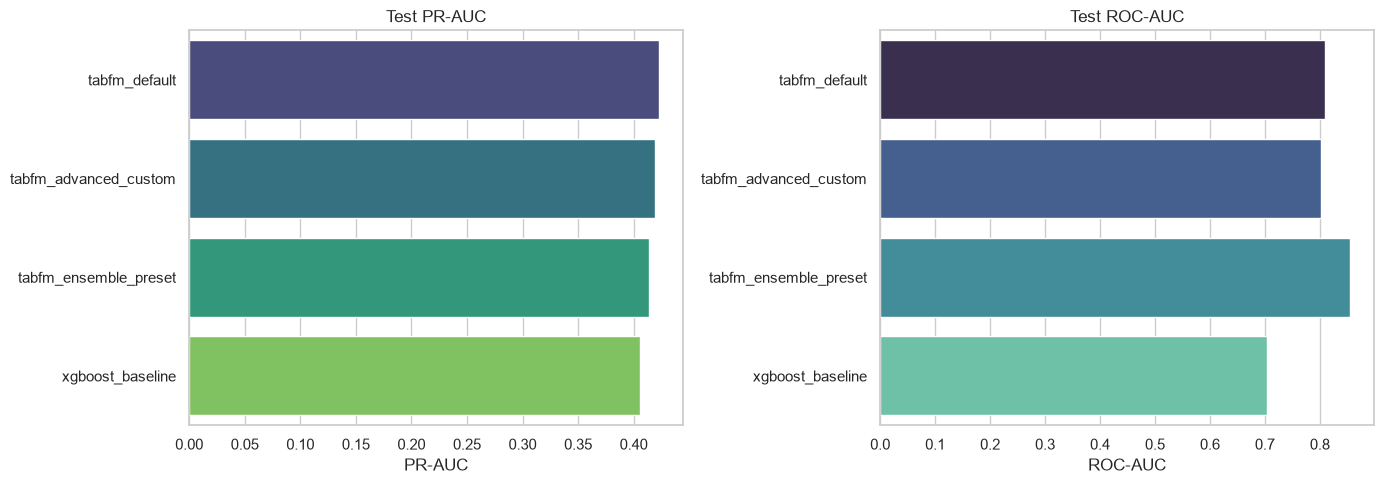

In [11]:
plot_df = metrics_df[metrics_df['split'] == 'test'].sort_values('pr_auc', ascending=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=plot_df, x='pr_auc', y='model', ax=axes[0], palette='viridis')
axes[0].set_title('Test PR-AUC')
axes[0].set_xlabel('PR-AUC')
axes[0].set_ylabel('')

sns.barplot(data=plot_df, x='roc_auc', y='model', ax=axes[1], palette='mako')
axes[1].set_title('Test ROC-AUC')
axes[1].set_xlabel('ROC-AUC')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

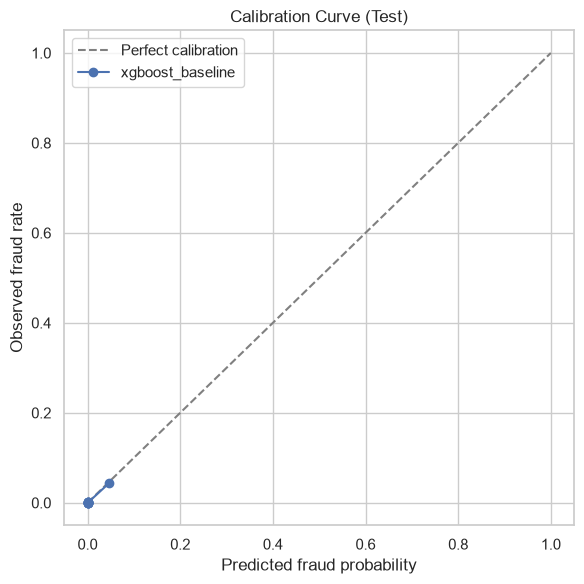

In [12]:
if len(champion_test_scores) != len(y_test):
    raise ValueError(f'Champion score mismatch: len(scores)={len(champion_test_scores)} len(y_test)={len(y_test)}')

prob_true, prob_pred = calibration_curve(y_test, champion_test_scores, n_bins=10, strategy='quantile')

plt.figure(figsize=(6, 6))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.plot(prob_pred, prob_true, marker='o', label=champion_model_name)
plt.title('Calibration Curve (Test)')
plt.xlabel('Predicted fraud probability')
plt.ylabel('Observed fraud rate')
plt.legend()
plt.tight_layout()
plt.show()

## 10) Decision policy: block, step-up auth, approve

We optimize thresholds using expected financial value.

Assumptions:
- Fraud blocked saves full transaction amount
- False positive incurs customer-friction/review cost
- Step-up zone handles medium-risk transactions

In [13]:
def optimize_threshold_by_value(
    y_true: np.ndarray,
    y_score: np.ndarray,
    amount: np.ndarray,
    false_positive_cost: float,
    grid_size: int = 401,
) -> tuple[pd.DataFrame, dict[str, float]]:
    thresholds = np.linspace(0.0, 1.0, grid_size)
    rows: list[dict[str, float]] = []

    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score).astype(float)
    amount = np.asarray(amount).astype(float)

    for thr in thresholds:
        pred = (y_score >= thr).astype(int)

        tp_mask = (pred == 1) & (y_true == 1)
        fp_mask = (pred == 1) & (y_true == 0)

        blocked_fraud_value = float(amount[tp_mask].sum())
        fp_count = int(fp_mask.sum())
        fp_total_cost = float(fp_count * false_positive_cost)
        net_value = blocked_fraud_value - fp_total_cost

        rows.append({
            'threshold': float(thr),
            'blocked_fraud_count': float(tp_mask.sum()),
            'blocked_fraud_value': blocked_fraud_value,
            'false_positive_count': float(fp_count),
            'false_positive_cost': fp_total_cost,
            'expected_net_value': net_value,
        })

    curve = pd.DataFrame(rows)
    best_idx = int(curve['expected_net_value'].idxmax())
    return curve, curve.loc[best_idx].to_dict()


BUSINESS_ASSUMPTIONS = {
    'false_positive_cost': 8.0,
}

val_amount = val_meta['Amount'].to_numpy(dtype=float)
test_amount = test_meta['Amount'].to_numpy(dtype=float)

threshold_curve_df, best_threshold_row = optimize_threshold_by_value(
    y_true=y_val,
    y_score=champion_val_scores,
    amount=val_amount,
    **BUSINESS_ASSUMPTIONS,
)
best_threshold = float(best_threshold_row['threshold'])
logger.info('Best threshold by validation net value: {:.3f}', best_threshold)

# Action policy bands.
medium_threshold = max(0.0, best_threshold - 0.10)

policy_df = test_meta.copy()
policy_df['is_fraud'] = y_test
policy_df['fraud_score'] = champion_test_scores
policy_df['decision'] = np.select(
    [
        policy_df['fraud_score'] >= best_threshold,
        policy_df['fraud_score'] >= medium_threshold,
    ],
    [
        'block',
        'step_up_auth',
    ],
    default='approve',
)

policy_summary = (
    policy_df.groupby('decision', dropna=False)
    .agg(
        txns=('transaction_id', 'count'),
        avg_amount=('Amount', 'mean'),
        fraud_rate=('is_fraud', 'mean'),
    )
    .reset_index()
    .sort_values('txns', ascending=False)
)

policy_summary

2026-07-03 03:40:14.309 | INFO     | __main__:<module>:54 - Best threshold by validation net value: 0.833


,decision,txns,avg_amount,fraud_rate
0,approve,7970,90.678261,0.001255
1,block,30,60.983000,1.000000


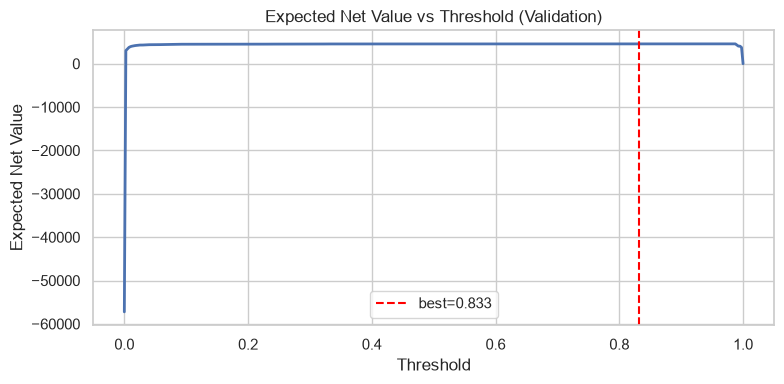

In [14]:
plt.figure(figsize=(8, 4))
sns.lineplot(data=threshold_curve_df, x='threshold', y='expected_net_value', linewidth=2)
plt.axvline(best_threshold, color='red', linestyle='--', label=f'best={best_threshold:.3f}')
plt.title('Expected Net Value vs Threshold (Validation)')
plt.xlabel('Threshold')
plt.ylabel('Expected Net Value')
plt.legend()
plt.tight_layout()
plt.show()

In [15]:
top_risky = (
    policy_df.sort_values('fraud_score', ascending=False)
    .head(20)
    .merge(test_df[['transaction_id', 'hour_of_day', 'amount_bucket', 'hour_bucket']], on='transaction_id', how='left')
)

cols = ['transaction_id', 'fraud_score', 'is_fraud', 'decision', 'Amount', 'hour_of_day', 'hour_bucket', 'amount_bucket']
top_risky[cols]

,transaction_id,fraud_score,is_fraud,decision,Amount,hour_of_day,hour_bucket,amount_bucket
0,229712,0.999803,1,block,1.18,16,afternoon,a1
1,42528,0.999785,1,block,340.11,11,morning,a9
2,6529,0.999754,1,block,1.00,2,night,a0
3,15810,0.999681,1,block,99.99,7,morning,a7
4,14197,0.999648,1,block,99.99,7,morning,a7
5,154719,0.999594,1,block,0.00,4,night,a0
6,151008,0.999498,1,block,1.00,2,night,a0
7,8845,0.999495,1,block,30.39,3,night,a5
8,43428,0.999490,1,block,364.19,11,morning,a9
9,42856,0.999461,1,block,173.07,11,morning,a8


## 11) Persist model evaluation and policy artifacts

In [16]:
metrics_path = ARTIFACT_DIR / 'problem3_fraud_model_metrics.csv'
pred_path = ARTIFACT_DIR / 'problem3_fraud_predictions_test.parquet'
policy_path = ARTIFACT_DIR / 'problem3_fraud_policy_actions.csv'
policy_summary_path = ARTIFACT_DIR / 'problem3_fraud_policy_summary.csv'
threshold_curve_path = ARTIFACT_DIR / 'problem3_fraud_threshold_curve.csv'
threshold_summary_path = ARTIFACT_DIR / 'problem3_fraud_threshold_summary.csv'
runtime_meta_path = ARTIFACT_DIR / 'problem3_fraud_runtime_meta.json'

prediction_frame = policy_df[[
    'transaction_id',
    'is_fraud',
    'fraud_score',
    'decision',
    'Amount',
]].copy()

metrics_df.to_csv(metrics_path, index=False)
policy_df.to_csv(policy_path, index=False)
policy_summary.to_csv(policy_summary_path, index=False)
threshold_curve_df.to_csv(threshold_curve_path, index=False)

threshold_summary_df = pd.DataFrame([
    {'split': 'validation', **best_threshold_row},
    {
        'split': 'test',
        **optimize_threshold_by_value(
            y_true=y_test,
            y_score=champion_test_scores,
            amount=test_amount,
            **BUSINESS_ASSUMPTIONS,
        )[1],
    },
])
threshold_summary_df.to_csv(threshold_summary_path, index=False)

# Avoid pandas->polars conversion path requiring pyarrow.
prediction_frame_cast = prediction_frame.copy()
prediction_frame_cast['transaction_id'] = prediction_frame_cast['transaction_id'].astype('int64')
prediction_frame_cast['is_fraud'] = prediction_frame_cast['is_fraud'].astype('int32')
prediction_frame_cast['fraud_score'] = prediction_frame_cast['fraud_score'].astype('float64')
prediction_frame_cast['decision'] = prediction_frame_cast['decision'].astype(str)
prediction_frame_cast['Amount'] = prediction_frame_cast['Amount'].astype('float64')

pred_pl = pl.DataFrame({col: prediction_frame_cast[col].tolist() for col in prediction_frame_cast.columns})
pred_pl.write_parquet(pred_path)

runtime_meta = {
    'seed': SEED,
    'data_url': DATA_URL,
    'sample_train_rows': int(SAMPLE_TRAIN_ROWS),
    'sample_eval_rows': int(SAMPLE_EVAL_ROWS),
    'tabfm_context_max_rows': int(TABFM_CONTEXT_MAX_ROWS),
    'tabfm_eval_max_rows': int(TABFM_EVAL_MAX_ROWS),
    'tabfm_fast_mode': bool(TABFM_FAST_MODE),
    'tabfm_device_preference': TABFM_DEVICE_PREF,
    'tabfm_device_effective': DEVICE,
    'tabfm_checkpoint': str(TABFM_CKPT_PATH),
    'champion_model': champion_model_name,
    'best_threshold': best_threshold,
    'business_assumptions': BUSINESS_ASSUMPTIONS,
}
runtime_meta_path.write_text(json.dumps(runtime_meta, indent=2))

for path in [
    metrics_path,
    pred_path,
    policy_path,
    policy_summary_path,
    threshold_curve_path,
    threshold_summary_path,
    runtime_meta_path,
]:
    logger.info('Wrote {}', path)

sorted(p.name for p in ARTIFACT_DIR.glob('problem3_fraud_*'))

2026-07-03 03:40:14.493 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_model_metrics.csv


2026-07-03 03:40:14.493 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_predictions_test.parquet


2026-07-03 03:40:14.493 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_policy_actions.csv


2026-07-03 03:40:14.494 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_policy_summary.csv


2026-07-03 03:40:14.494 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_threshold_curve.csv


2026-07-03 03:40:14.494 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_threshold_summary.csv


2026-07-03 03:40:14.494 | INFO     | __main__:<module>:73 - Wrote /home/ahmad/AI/Github/google-tabFM-implementation/problems/problem3_credit_card_transaction_fraud/artifacts/problem3_fraud_runtime_meta.json


['problem3_fraud_model_metrics.csv',
 'problem3_fraud_policy_actions.csv',
 'problem3_fraud_policy_summary.csv',
 'problem3_fraud_predictions_test.parquet',
 'problem3_fraud_runtime_meta.json',
 'problem3_fraud_threshold_curve.csv',
 'problem3_fraud_threshold_summary.csv']

## 12) Operational interpretation

How to use in production:
- `decision=block`: hard decline or immediate fraud hold
- `decision=step_up_auth`: trigger OTP/challenge/manual review
- `decision=approve`: normal approval path

Recommended next hardening steps:
1. Add temporal backtesting (train older, test newer windows)
2. Add drift monitoring (score distribution + fraud rate shift)
3. Calibrate thresholds by region/card-product/customer segment
4. Integrate human-review outcomes as weak labels for continuous retraining